In [4]:
from autoemulate import AutoEmulate
import torch
import pandas as pd
from pathlib import Path
from sparging.config import ureg

# FOLDER = Path("/home/monroe/libra_pi/libra_sparging/20260422_164947")
FOLDER = Path("datasets/20260424_131925")
t_residual = 7 * ureg.day

# model = AutoEmulate.load_model(FOLDER / "GaussianProcessRBF_1_20260422_165335.joblib")


In [5]:
X = pd.read_csv(FOLDER / "simulator_inputs.csv")
Y = pd.read_csv(FOLDER / "simulator_outputs.csv")
Z = torch.tensor(Y.values, dtype=torch.float32)

/tmp/ipykernel_83803/3239760125.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


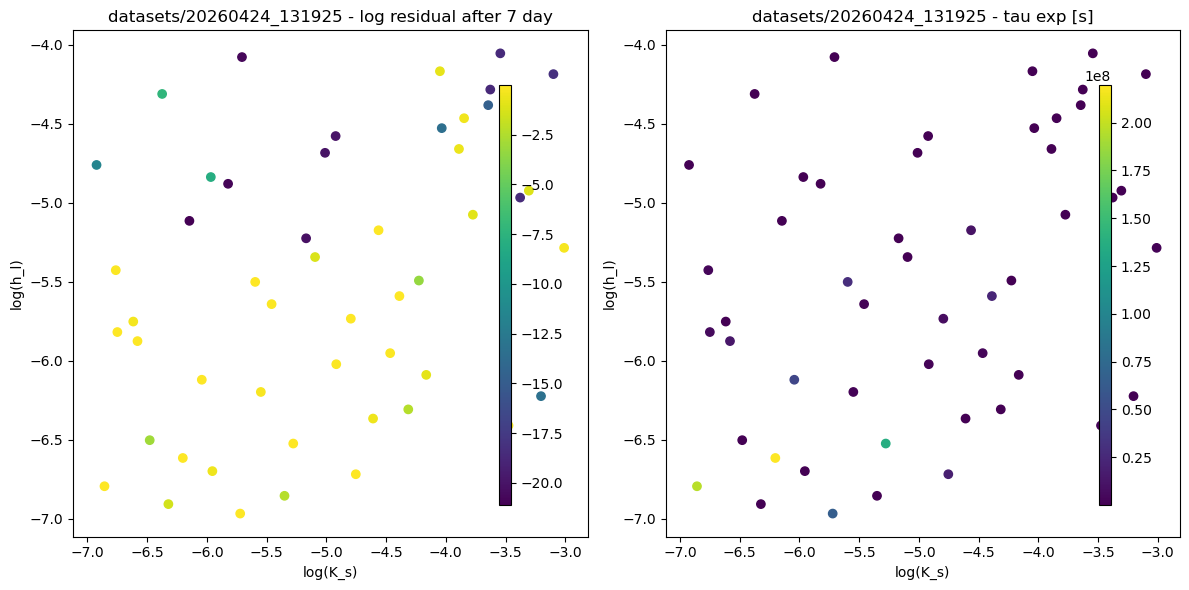

In [6]:
import matplotlib.pyplot as plt
import numpy as np

y_log = True
x_name = "log(K_s)"
y_name = "log(h_l)"
c_name = f"log(residual_{t_residual:.0f})"
Y_plot = [Y[c_name] if y_log is True else np.power(10, Y[c_name]), Y["tau_exp"].values]

fig,axs = plt.subplots(1,2, figsize=(12,6))
plt.sca(axs[0])
plt.scatter(X[x_name], X[y_name], c=Y_plot[0], cmap="viridis", vmin=Y_plot[0].min(), vmax=Y_plot[0].max())

plt.title(f"{FOLDER} - {"log" if y_log else ""} residual after {t_residual:.0f}")

plt.xlabel(x_name)
plt.ylabel(y_name)
plt.colorbar(cax=fig.add_axes([0.42, 0.15, 0.01, 0.7]))

plt.sca(axs[1])
plt.scatter(X[x_name], X[y_name], c=Y_plot[1], cmap="viridis", vmin=Y_plot[1].min(), vmax=Y_plot[1].max())

plt.title(f"{FOLDER} - tau exp [s]")

plt.xlabel(x_name)
plt.ylabel(y_name)

plt.colorbar(cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))
fig.tight_layout()
plt.savefig(FOLDER / "postprocessing" / "scatter.png")

# plt.show()

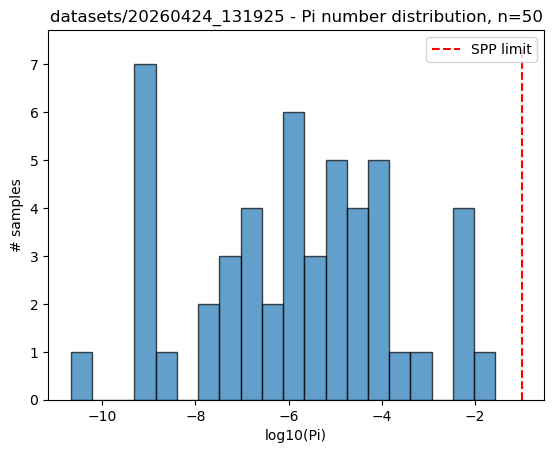

In [7]:
PP_data = pd.read_csv(FOLDER / "PP_numbers.csv")

plt.hist(np.log10(PP_data["PP_number"].values), bins=20, edgecolor='black', alpha=0.7)
plt.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
plt.title(f"{FOLDER} - Pi number distribution, n={len(PP_data)}")
plt.xlabel("log10(Pi)")
plt.ylabel("# samples")
plt.legend()
plt.savefig(FOLDER / "postprocessing" / "PI_distrib.png")

In [8]:
""" PP number range from input parameters range"""

parameters_range={
        "log(h_l)": tuple(np.log10((1e-4, 1e-2))),
        "log(eps_g)": tuple(np.log10((1e-4, 2e-1))),
        "a": (0.05, 0.5),
        "temperature": (450, 800),
        "log(K_s)": tuple(np.log10((1e-3, 1e-0))),
        "u_g0": (0.02, 0.4),
    }
p = parameters_range
PP_max = 8.314 * (np.max(p["temperature"])+273) * 10**np.max(p["log(K_s)"]) * 10**np.max(p["log(h_l)"]) * np.max(p["a"]) * 1 / ((1-10**np.max(p["log(eps_g)"])) * np.min(p["u_g0"]))
PP_min = 8.314 * (np.min(p["temperature"])+273) * 10**np.min(p["log(K_s)"]) * 10**np.min(p["log(h_l)"]) * np.min(p["a"]) * 1 / ((1-10**np.min(p["log(eps_g)"])) * np.max(p["u_g0"]))
print(f"PP range: {PP_min:.2e} - {PP_max:.2e}")

PP range: 7.51e-05 - 2.79e+03


Monte Carlo samples: 50000

PP STATISTICS
  Min:        6.16e-03
  Max:        9.40e+01
  Mean:       2.56e+00
  Std:        4.94e+00
  Median:     7.97e-01
  log10 range: [-2.21, 1.97]


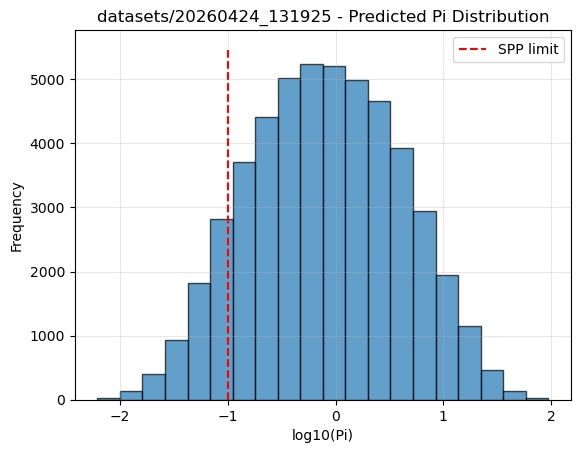

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_pp_sample(parameters_range, n_samples=10000):
    R = 8.314  # Gas constant J/(mol·K)
    
    # Initialize storage for samples
    samples = {key: np.zeros(n_samples) for key in parameters_range.keys()}
    # Sample uniformly from each parameter range
    for param, (min_val, max_val) in parameters_range.items():
        samples[param] = np.random.uniform(min_val, max_val, n_samples)
    
    # Compute PP for each sample
    Pi_values = (
        R * 
        (samples["temperature"] + 273) * 
        10**samples["log(K_s)"] * 
        10**samples["log(h_l)"] * 
        # 10**samples["log(a)"] / 
        samples["a"] /
        ((1 - 10**samples["log(eps_g)"]) * samples["u_g0"])
    )
    
    return Pi_values, samples


parameters_range={
    "log(h_l)": tuple(np.log10((1e-3, 1e-2))),
    "log(eps_g)": tuple(np.log10((1e-4, 2e-1))),
    "a": (0.05, 0.3),
    "temperature": (700, 800),
    "log(K_s)": tuple(np.log10((1e-3, 1e-1))),
    "u_g0": (0.02, 0.1),
}

# parameters_range={
#         "log(h_l)": tuple(np.log10((1e-7, 1e-4))),
#         "log(eps_g)": tuple(np.log10((1e-4, 2e-1))),
#         "log(a)": tuple(np.log10((1e-2, 1e2))),
#         "temperature": (450, 800),
#         "log(K_s)": tuple(np.log10((1e-7, 1e-3))),
#         "u_g0": (0.02, 0.4),
#         "E_l": tuple(np.log10((1e-3, 1e0))),
#         "E_g": tuple(np.log10((1e-4, 1e-1))),
#         "P_bottom": (1, 10),
#     }

# Run Monte Carlo
n_samples = 50000
pp_values, samples = monte_carlo_pp_sample(parameters_range, n_samples)

# Statistics
print(f"Monte Carlo samples: {n_samples}")
print(f"\n{'='*50}")
print(f"PP STATISTICS")
print(f"{'='*50}")
print(f"  Min:        {np.min(pp_values):.2e}")
print(f"  Max:        {np.max(pp_values):.2e}")
print(f"  Mean:       {np.mean(pp_values):.2e}")
print(f"  Std:        {np.std(pp_values):.2e}")
print(f"  Median:     {np.median(pp_values):.2e}")
print(f"  log10 range: [{np.log10(np.min(pp_values)):.2f}, {np.log10(np.max(pp_values)):.2f}]")

# Visualization
fig_MC, ax = plt.subplots()

# PP distribution (log scale)
ax.hist(np.log10(pp_values), bins=20,edgecolor='black', alpha=0.7)
# ax.hist(pp_values, bins=50, range=(0,10),edgecolor='black', alpha=0.7)

ax.set_xlabel("log10(Pi)")
ax.set_ylabel("Frequency")
ax.set_title(f"{FOLDER} - Predicted Pi Distribution")
ax.grid(alpha=0.3)
ax.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
# ax.vlines(0.1, ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")

ax.legend()

In [10]:
# fig_MC.savefig(FOLDER / "postprocessing" / "PI_monte_carlo.png", dpi=150)

Diagnostic for sample 5: PP=1.3028055800782978e-06, residual=2.90e-12


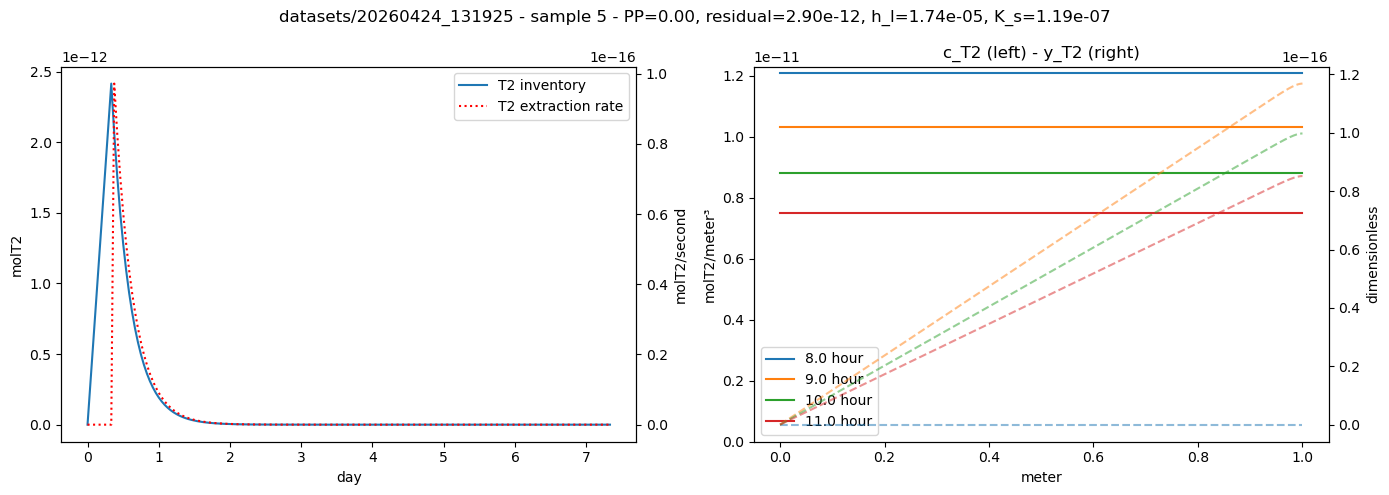

In [11]:
""" sample inspection"""
from sparging.model import SimulationResults
from sparging.config import ureg
import sparging.postprocess as pp

idxs = np.argwhere(PP_data["PP_number"].values > 1)
# idx = idxs[0,0]
idx = 5
print(f"Diagnostic for sample {idx}: PP={PP_data['PP_number'].values[idx]}, residual={10**Y[f'log(residual_{t_residual:.0f})'].values[idx]:.2e}")
sim_result = SimulationResults.from_json(FOLDER/"samples"/f"sample_{idx}.json")

fig, axs = plt.subplots(1,2, figsize=(14,5))
secax0 = axs[0].twinx()
secax1 = axs[1].twinx()
lns1 = axs[0].plot(sim_result.times, sim_result.n_T2_salt_series, label="T2 inventory")
lns2 = secax0.plot(sim_result.times, sim_result.fluxes_T2, color="red", linestyle=":", label="T2 extraction rate")
lns = lns1 + lns2 
labels = [l.get_label() for l in lns]
axs[0].legend(lns, labels)
axs[0].xaxis.set_units(ureg.day)

for t in [8, 9, 10, 11]*ureg.hour:
    idx_to_plot = pp.idx_from_t(sim_result.times, t)
    time = sim_result.times[idx_to_plot].to(t.units)
    axs[1].plot(sim_result.x_ct, sim_result.c_T2_profiles[idx_to_plot], label=f"{time:.1f}")
    secax1.plot(sim_result.x_ct, sim_result.y_T2_profiles[idx_to_plot], linestyle="--", alpha=0.5)
axs[1].set_ylim(0)
axs[1].set_title("c_T2 (left) - y_T2 (right)")
axs[1].legend()
fig.suptitle(f"{FOLDER} - sample {idx} - PP={PP_data['PP_number'].values[idx]:.2f}, residual={10**Y[f'log(residual_{t_residual:.0f})'].values[idx]:.2e}, h_l={10**X['log(h_l)'].values[idx]:.2e}, K_s={10**X['log(K_s)'].values[idx]:.2e}")
fig.tight_layout()

FOLDER_PP = FOLDER / "postprocessing"
FOLDER_PP.mkdir(exist_ok=True)
fig.savefig(FOLDER_PP / f"diagnostic_sample_{idx}.png", dpi=150)

Text(0.5, 0.98, 'sample 5, tau = 22766.58 second, n0=2.42e-12 molT2')

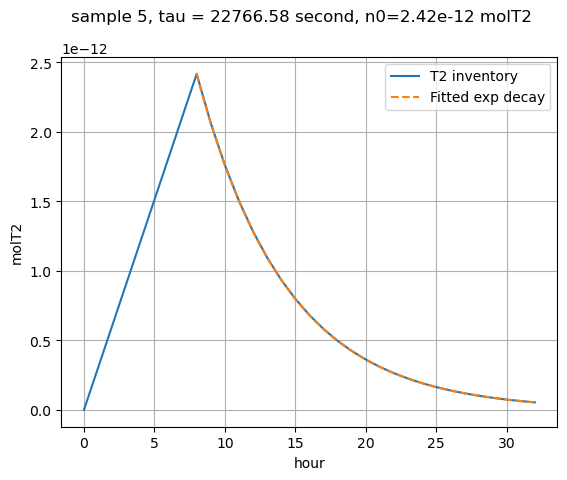

In [12]:
""" plot fit of sample """
t_0 = 8 * ureg.hour
t_plot = 32 * ureg.hour
idx_0 = pp.idx_from_t(sim_result.times, t_0)
idx_plot = pp.idx_from_t(sim_result.times, t_plot)

tau_exp = PP_data["tau_exp"].values[idx] * ureg.second
n0 = sim_result.n_T2_salt_series[idx_0]

fig,ax = plt.subplots(1,1)
ax.plot(sim_result.times[:idx_plot+1], sim_result.n_T2_salt_series[:idx_plot+1], label="T2 inventory")
t_fit = np.linspace(8 * ureg.hour, t_plot, 100)
ax.plot(t_fit, n0 * np.exp(-(t_fit-t_0) / tau_exp), label="Fitted exp decay", linestyle="--")
ax.legend()
ax.xaxis.set_units(ureg.hour)
ax.grid()

fig.suptitle(f"sample {idx}, tau = {tau_exp.to('s'):.2f}, n0={n0:.2e}")

Text(0.5, 1.0, 'datasets/20260424_131925 - log residual after 7 day')

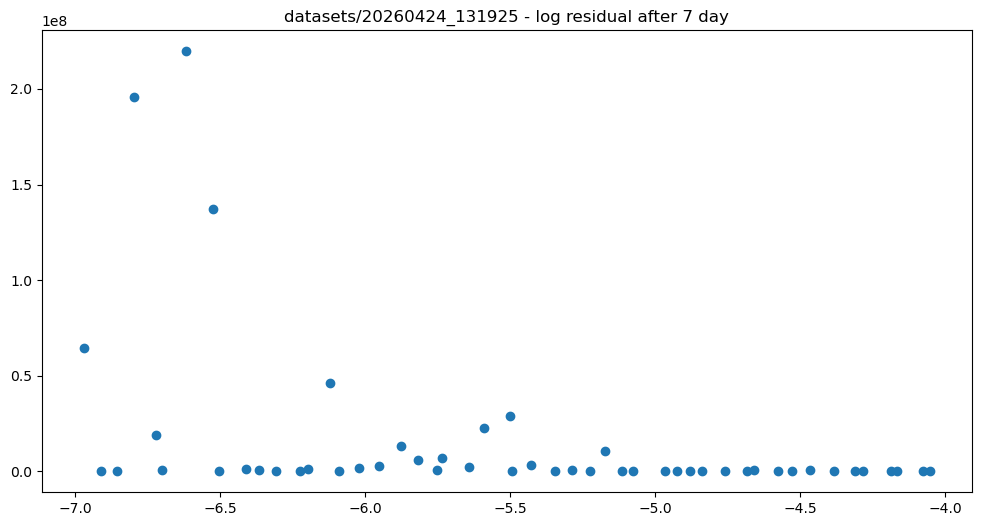

In [17]:

y_log = True
x_name = "log(K_s)"
y_name = "log(h_l)"
c_name = f"log(residual_{t_residual:.0f})"
Y_plot = [Y[c_name] if y_log is True else np.power(10, Y[c_name]), Y["tau_exp"].values]

fig,axs = plt.subplots(1,1, figsize=(12,6))

plt.scatter(X["log(h_l)"], Y["tau_exp"])

plt.title(f"{FOLDER} - {"log" if y_log else ""} residual after {t_residual:.0f}")

# plt.savefig(FOLDER / "postprocessing" / "scatter.png")

# plt.show()